In [4]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pygame # For rendering and image handling
import time


from causal_gym.envs import LunarLanderPCH

def create_lander_env(render_mode='rgb_array', wind_mean=0.0, wind_std=0.2, max_steps=1000):
    """Helper function to create a LunarLanderPCH environment."""
    try:
        env = LunarLanderPCH(
            render_mode=render_mode, 
            wind_mean=wind_mean, 
            wind_std=wind_std,
            max_episode_steps=max_steps
        )
        print(f"LunarLanderPCH created with wind_mean={wind_mean}, wind_std={wind_std}, render_mode='{render_mode}'")
        return env
    except Exception as e:
        print(f"Error creating LunarLanderPCH: {e}")
        return None

def run_episode(env, policy=None, max_steps=500, render_frames=True, print_wind=True):
    """Runs a single episode in the environment and optionally renders it."""
    if env is None:
        print("Environment is None, cannot run episode.")
        return [], 0, False

    frames = []
    try:
        obs, info = env.reset()
        if print_wind and hasattr(env, 'current_wind') and env.current_wind is not None:
            print(f"Episode Wind: {env.current_wind:.2f}")
        else:
            if print_wind:
                print("Could not retrieve current_wind from environment.")

    except Exception as e:
        print(f"Error during env.reset(): {e}")
        return [], 0, False
        
    total_reward = 0
    terminated = False
    truncated = False
    
    for step_count in range(max_steps):
        if render_frames:
            try:
                frame = env.render()
                if frame is not None:
                    frames.append(frame)
                else:
                    # If render_mode is human, frame might be None but rendering happens in a window
                    if env._env.render_mode == 'human':
                        pygame.display.flip() # Ensure display updates
                        time.sleep(0.03) # Small delay for human viewing
                    else:
                        print(f"Warning: env.render() returned None at step {step_count} for mode {env._env.render_mode}")
            except Exception as e:
                print(f"Error during env.render() at step {step_count}: {e}")
                break # Stop if rendering fails

        if policy is None:
            action = env.action_space.sample() # Random action
        else:
            action = policy(obs) # Policy-based action
        
        try:
            obs, reward, terminated, truncated, info = env.step(action)
        except Exception as e:
            print(f"Error during env.step() at step {step_count}: {e}")
            break # Stop if step fails
            
        total_reward += reward
        if terminated or truncated:
            break
            
    print(f"Episode finished after {step_count + 1} steps. Total reward: {total_reward:.2f}")
    if terminated:
        print("Lander landed successfully or crashed.")
    if truncated:
        print("Episode truncated (max steps reached).")
        
    return frames, total_reward, terminated

def display_frames(frames, figsize=(10, 8)):
    """Displays a list of frames (RGB arrays) as an animation or sequence."""
    if not frames:
        print("No frames to display.")
        return
    
    # Check if frames are Pygame surfaces or numpy arrays
    if isinstance(frames[0], np.ndarray):
        # Simple display for a few frames, or animate if many
        if len(frames) <= 5:
            fig, axes = plt.subplots(1, len(frames), figsize=figsize)
            if len(frames) == 1:
                axes = [axes] # make it iterable
            for i, frame in enumerate(frames):
                axes[i].imshow(frame)
                axes[i].axis('off')
            plt.tight_layout()
            plt.show()
        else: # Animation for many frames
            fig = plt.figure(figsize=figsize)
            plt.axis('off')
            img_display = plt.imshow(frames[0])
            def animate(i):
                img_display.set_data(frames[i])
                return [img_display]
            
            from matplotlib.animation import FuncAnimation
            anim = FuncAnimation(fig, animate, frames=len(frames), interval=50, blit=True)
            from IPython.display import HTML
            plt.close(fig) # close the static plot
            display(HTML(anim.to_jshtml()))
            print("Displaying animation.")

    elif hasattr(frames[0], 'get_width'): # Heuristic for Pygame surface (not perfectly robust)
        print("Frames seem to be Pygame surfaces. Consider converting to numpy arrays for display in notebook or ensure human mode rendering is active.")
    else:
        print("Unknown frame format.")

print("Helper functions defined.")

Helper functions defined.


In [6]:
from causal_gym.core import Task

print(Task("do", "mdp", None, "discount"))

Task(learning_regime='do', assumptions='mdp', policy_space=None, reward_func='discount')


LunarLanderPCH created with wind_mean=0.0, wind_std=0.0, render_mode='rgb_array'
b2Vec2(9.92894,13.3833)
[-0.0071063   1.4174945  -0.71979153  0.2921823   0.00824106  0.1630436
  0.          0.        ]
(400, 600, 3)


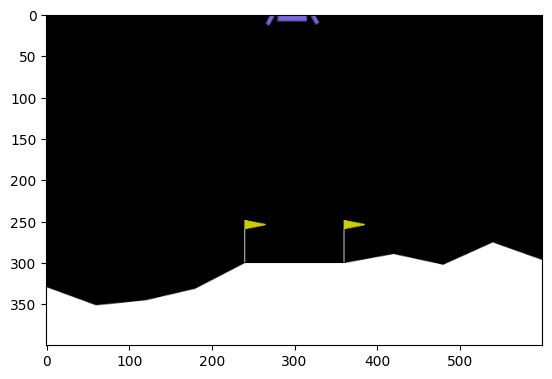

In [2]:
env = create_lander_env(render_mode='rgb_array', wind_mean=0.0, wind_std=0.0, max_steps=1000)
state, info = env.reset()
obs = env.render()
print(env.unwrapped.lander.position)
print(state)
print(obs.shape)
plt.imshow(obs)
plt.show()

In [3]:
print(env.env.wind_map[np.floor(env.unwrapped.lander.position.y).astype(int)][np.floor(env.unwrapped.lander.position.x).astype(int)])
# state, reward, term, trunc, info = env.step(0)
state, reward, term, trunc, info = env.ctf_do(lambda obs, intuition: intuition)
print(env.current_wind)
# print(env.wind_map)
print(env.unwrapped.lander.position)
print(env._natural_action)
# env.unwrapped.lander.position.x = 10
# env.unwrapped.lander.position.y = 15
# print(env.unwrapped.lander.position)
obs = env.render(show_wind=True, show_natural_action=True)
plt.imshow(obs)
plt.show()

0.0


AttributeError: 'LunarLanderPCH' object has no attribute 'task'

In [ ]:
# Cell 3: Test - Standard Lunar Lander (No Wind)
print("--- Test: Standard Lunar Lander (No Wind) ---")

# Create environment with no wind
# Using rgb_array for capturing frames
env_no_wind = create_lander_env(render_mode='rgb_array', wind_mean=0.0, wind_std=0.0, max_steps=300)

if env_no_wind:
    # Run an episode with random actions
    print("Running episode with random policy...")
    frames_no_wind, reward_no_wind, landed_no_wind = run_episode(env_no_wind, policy=None, max_steps=300, render_frames=True)
    
    # Display the frames
    if frames_no_wind:
        print("Displaying episode frames...")
        display_frames(frames_no_wind, figsize=(12,9))
    else:
        print("No frames were captured for the no-wind scenario.")
    
    env_no_wind.close()
    print("No-wind environment closed.")
else:
    print("Failed to create no-wind environment.")

print("--- End Test: Standard Lunar Lander (No Wind) ---")

In [ ]:
# Cell 4: Test - Lunar Lander with Positive Wind (pushes lander Right)
print("--- Test: Lunar Lander with Positive Wind (Wind from Left) ---")

# Define wind parameters - positive mean for wind from the left
WIND_STRENGTH_POSITIVE = 15.0 # Stronger wind for clear effect
WIND_STD_DEV = 2.0

# Create environment with positive wind
env_positive_wind = create_lander_env(
    render_mode='rgb_array', 
    wind_mean=WIND_STRENGTH_POSITIVE, 
    wind_std=WIND_STD_DEV, 
    max_steps=300
)

if env_positive_wind:
    print(f"Running episode with positive wind (mean={WIND_STRENGTH_POSITIVE})...")
    frames_positive_wind, reward_positive_wind, landed_positive_wind = run_episode(
        env_positive_wind, 
        policy=None, 
        max_steps=300, 
        render_frames=True
    )
    
    if frames_positive_wind:
        print("Displaying episode frames with positive wind...")
        display_frames(frames_positive_wind, figsize=(12,9))
    else:
        print("No frames were captured for the positive-wind scenario.")
        
    env_positive_wind.close()
    print("Positive-wind environment closed.")
else:
    print("Failed to create positive-wind environment.")

print("--- End Test: Lunar Lander with Positive Wind ---")

In [ ]:
# Cell 5: Test - Lunar Lander with Negative Wind (pushes lander Left)
print("--- Test: Lunar Lander with Negative Wind (Wind from Right) ---")

# Define wind parameters - negative mean for wind from the right
WIND_STRENGTH_NEGATIVE = -15.0 # Stronger wind for clear effect
# WIND_STD_DEV is already defined or use a new one if needed, e.g., 2.0

# Create environment with negative wind
env_negative_wind = create_lander_env(
    render_mode='rgb_array', 
    wind_mean=WIND_STRENGTH_NEGATIVE, 
    wind_std=WIND_STD_DEV, # Using the same std dev as positive wind test
    max_steps=300
)

if env_negative_wind:
    print(f"Running episode with negative wind (mean={WIND_STRENGTH_NEGATIVE})...")
    frames_negative_wind, reward_negative_wind, landed_negative_wind = run_episode(
        env_negative_wind, 
        policy=None, 
        max_steps=300, 
        render_frames=True
    )
    
    if frames_negative_wind:
        print("Displaying episode frames with negative wind...")
        display_frames(frames_negative_wind, figsize=(12,9))
    else:
        print("No frames were captured for the negative-wind scenario.")
        
    env_negative_wind.close()
    print("Negative-wind environment closed.")
else:
    print("Failed to create negative-wind environment.")

print("--- End Test: Lunar Lander with Negative Wind ---")

In [ ]:
# Cell 6: Test - Observing Success/Failure with Moderate Wind
print("--- Test: Observing Success/Failure with Moderate Wind ---")

# Moderate wind that might allow for both success and failure with a random policy
MODERATE_WIND_MEAN = 5.0 
MODERATE_WIND_STD = 1.0
NUM_EPISODES_OBSERVE = 3 # Run a few episodes to see different outcomes

env_observe = create_lander_env(
    render_mode='rgb_array', 
    wind_mean=MODERATE_WIND_MEAN, 
    wind_std=MODERATE_WIND_STD, 
    max_steps=400 # Slightly longer episodes
)

if env_observe:
    for i in range(NUM_EPISODES_OBSERVE):
        print(f"\n--- Running Observation Episode {i+1}/{NUM_EPISODES_OBSERVE} with moderate wind (mean={MODERATE_WIND_MEAN}) ---")
        frames_observe, reward_observe, landed_observe = run_episode(
            env_observe, 
            policy=None, 
            max_steps=400, 
            render_frames=True
        )
        
        if frames_observe:
            print(f"Displaying frames for episode {i+1}...")
            display_frames(frames_observe, figsize=(12,9))
            if landed_observe:
                print(f"Outcome for episode {i+1}: Successful landing (or crash, reward: {reward_observe:.2f})")
            else:
                print(f"Outcome for episode {i+1}: Episode truncated (reward: {reward_observe:.2f})")
        else:
            print(f"No frames captured for observation episode {i+1}.")
        print("-----------------------------------------------------")
            
    env_observe.close()
    print("Observation environment closed.")
else:
    print("Failed to create environment for observing success/failure.")

print("--- End Test: Observing Success/Failure with Moderate Wind ---")

In [ ]:
# Cell 7: Cleanup
# Though environments are closed in each test cell, this is a placeholder for any global cleanup if needed.

# For example, if Pygame was initialized globally:
# pygame.quit()

print("Notebook execution complete. All test environments should be closed.")
print("If you ran any cells with render_mode='human', ensure Pygame windows are closed manually if they persist.")